# GRAHSP: Single Chimera Stellar-Mass Fit

This notebook mirrors the single-object flow in `01_example.ipynb`, but it uses the original GRAHSP fitter (`sampler/dualsampler.py`) instead of `grahspj`. It loads one object from the Chimera benchmark, writes a GRAHSP/CIGALE-style photometry table and `pcigale.ini`, runs the nested-sampling fitter, and compares the recovered stellar mass to the Chimera truth value.

## Setup

Run this notebook from `grahspj/notebooks`. The `astro` environment should have the editable GRAHSP install available, including the rebuilt `cigale/pcigale/data/data.db` database.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys
import textwrap

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "grahspj" / "src").is_dir() and (path / "sampler" / "dualsampler.py").is_file():
            return path
    raise RuntimeError("Could not find the GRAHSP repository root from the current directory.")

repo_root = find_repo_root()
grahspj_root = repo_root / "grahspj"
src_root = grahspj_root / "src"
cigale_root = repo_root / "cigale"
sampler_script = repo_root / "sampler" / "dualsampler.py"

for path in (src_root, cigale_root):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from grahspj.benchmark import load_chimera_benchmark_dataset, select_chimera_subset

print("repo_root:", repo_root)
print("sampler:", sampler_script)

repo_root: /home/nicho/GRAHSP
sampler: /home/nicho/GRAHSP/sampler/dualsampler.py


## Pick A Chimera Object

Set `target_object_id` to any Chimera benchmark object id. The default is the same deterministic tutorial object used in `01_example.ipynb`.

In [2]:
dataset = load_chimera_benchmark_dataset(grahspj_root)
subset = select_chimera_subset(dataset, grahspj_root)

print(f"Loaded {len(dataset.rows)} full Chimera benchmark rows")
print(f"Loaded {len(subset)} deterministic tutorial subset rows")
print("Example object IDs:", [str(r["id"]) for r in subset[:5]])

target_object_id = "081636.18+294135.7_473476_0.0003"

row = next((r for r in dataset.rows if str(r["id"]) == target_object_id), None)
if row is None:
    raise ValueError(f"target_object_id={target_object_id!r} was not found in the Chimera benchmark")

truth_logm = float(row["log_stellar_mass_truth"])
print("object_id:", row["id"])
print("COSMOS ID:", row["ID_COSMOS"])
print("redshift:", row["redshift"])
print("chimera_QSO_weight:", row["chimera_QSO_weight"])
print("truth log stellar mass:", truth_logm)

[benchmark] Loading Chimera photometry from /home/nicho/GRAHSP/grahspj/data/chimeras-2023-10-11/chimeras-grahsp.fits
[benchmark] Loading Chimera truth table from /home/nicho/GRAHSP/grahspj/data/chimeras-2023-10-11/chimeras-fullinfo.fits
[benchmark] Joined 18168 Chimera rows
[benchmark] Loading deterministic subset from /home/nicho/GRAHSP/grahspj/data/chimeras-2023-10-11/benchmark_subset_ids.txt
[benchmark] Selected 1 benchmark rows
Loaded 18168 full Chimera benchmark rows
Loaded 1 deterministic tutorial subset rows
Example object IDs: ['011521.37+311730.6_386291_0.0003']
object_id: 081636.18+294135.7_473476_0.0003
COSMOS ID: 473476
redshift: 0.26499998569488525
chimera_QSO_weight: 0.0003
truth log stellar mass: 8.82973


## Write GRAHSP Inputs

GRAHSP expects a CIGALE-style table with `id`, `redshift`, and one flux/error pair per filter, in mJy. The Chimera benchmark stores the IRAC columns as `spitzer.irac.I1/I2` in `grahspj`; the GRAHSP database calls those filters `IRAC1/IRAC2`.

In [3]:
output_dir = grahspj_root / "notebook_outputs" / "12_grahsp_chimera_stellar_mass" / str(row["id"])
output_dir.mkdir(parents=True, exist_ok=True)

chimera_to_grahsp_filters = {
    "u_sdss": "u_sdss",
    "r_sdss": "r_sdss",
    "i_sdss": "i_sdss",
    "z_sdss": "z_sdss",
    "J_2mass": "J_2mass",
    "H_2mass": "H_2mass",
    "Ks_2mass": "Ks_2mass",
    "spitzer.irac.I1": "IRAC1",
    "spitzer.irac.I2": "IRAC2",
}

table_data = {
    "id": [str(row["id"])],
    "redshift": [float(row["redshift"])],
    "redshift_err": [0.0],
}
for chimera_name, grahsp_name in chimera_to_grahsp_filters.items():
    flux = float(row[chimera_name])
    err = float(row[f"{chimera_name}_err"])
    table_data[grahsp_name] = [flux if np.isfinite(flux) else -9999.0]
    table_data[f"{grahsp_name}_err"] = [err if np.isfinite(err) and err > 0 else -9999.0]

input_table = Table(table_data)
input_path = output_dir / "chimera_object.ecsv"
input_table.write(input_path, format="ascii.ecsv", overwrite=True)

input_table
print("Wrote", input_path)

Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/12_grahsp_chimera_stellar_mass/081636.18+294135.7_473476_0.0003/chimera_object.ecsv


## Build `pcigale.ini`

This is a compact GRAHSP configuration for a single-object benchmark run. It uses Maraston stellar populations, the Activate AGN components, bi-attenuation, host dust re-emission, and redshifting. The grids are intentionally modest so the notebook is usable interactively; widen them for production work.

In [4]:
filters = list(chimera_to_grahsp_filters.values())
column_list = []
for name in filters:
    column_list.extend([name, f"{name}_err"])

pcigale_ini = f"""
data_file = {input_path}
column_list = {', '.join(column_list)}
creation_modules = sfh2exp, m2005, nebular, activate, activatelines, activategtorus, activatepl, activatebol, biattenuation, galdale2014, redshifting
analysis_method = pdf_analysis
cores = 1
cosmology = concordance

[statistics]
  exponent = 2
  systematics_width = 0.03
  variability_uncertainty = true
  attenuation_model_uncertainty = false
  Ly_break_uncertainty = false

[sed_creation_modules]
  [[sfh2exp]]
    tau_main = 500, 1500, 4000, 8000
    tau_burst = 50
    f_burst = 0.0, 0.01, 0.1
    age = 500, 1000, 3000, 6000, 9000, 12000
    burst_age = 20, 100
    sfr_0 = 1
    normalise = True

  [[m2005]]
    imf = 1
    metallicity = 0.02
    separation_age = 10

  [[nebular]]
    logU = -2.0
    zgas = 0.02
    ne = 100
    f_esc = 0.0
    f_dust = 0.0
    lines_width = 300
    emission = True

  [[activate]]
    fracAGN = -1

  [[activatelines]]
    AFeII = 5
    AGNtype = 1
    linewidth = 3000
    Alines = 1
    ABC = 0

  [[activategtorus]]
    fcov = 0.05, 0.2, 0.5
    Si = 0
    COOLlam = 17
    COOLwidth = 0.45
    HOTlam = 2.0
    HOTwidth = 0.5
    HOTfcov = 0.0, 0.5
    SiRatio = 0.29
    SiEmlam = 9841
    SiAbslam = 14224
    SiEmWidth = 1025.3
    SiAbsWidth = 1163.5

  [[activatepl]]
    plslope = -1.8
    plbendloc = 90
    plbendwidth = 0.5
    uvslope = 0
    cutoff = 10000

  [[activatebol]]

  [[biattenuation]]
    OPT_index = -1.2
    NIR_index = -3.0
    norm = 1.2
    lam_break = 1100
    E(B-V) = 0.001, 0.01, 0.1
    E(B-V)-AGN = 0.001, 0.03, 0.3, 1.0
    filters =

  [[galdale2014]]
    alpha = 2.0
    lam_max = -1

  [[redshifting]]
    redshift =

[analysis_configuration]
  analysed_variables = stellar.mass_total, stellar.mass_alive, sfh.sfr, sfh.sfr100Myrs, agn.lumBolBBB, agn.lumBolTOR, agn.fracAGNDale
  save_best_sed = False
  save_chi2 = False
  save_pdf = False
  lim_flag = False
  mock_flag = False
"""

config_path = output_dir / "pcigale.ini"
config_path.write_text(textwrap.dedent(pcigale_ini).strip() + "\n")
print("Wrote", config_path)
print(config_path.read_text()[:1200])

Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/12_grahsp_chimera_stellar_mass/081636.18+294135.7_473476_0.0003/pcigale.ini
data_file = /home/nicho/GRAHSP/grahspj/notebook_outputs/12_grahsp_chimera_stellar_mass/081636.18+294135.7_473476_0.0003/chimera_object.ecsv
column_list = u_sdss, u_sdss_err, r_sdss, r_sdss_err, i_sdss, i_sdss_err, z_sdss, z_sdss_err, J_2mass, J_2mass_err, H_2mass, H_2mass_err, Ks_2mass, Ks_2mass_err, IRAC1, IRAC1_err, IRAC2, IRAC2_err
creation_modules = sfh2exp, m2005, nebular, activate, activatelines, activategtorus, activatepl, activatebol, biattenuation, galdale2014, redshifting
analysis_method = pdf_analysis
cores = 1
cosmology = concordance

[statistics]
  exponent = 2
  systematics_width = 0.03
  variability_uncertainty = true
  attenuation_model_uncertainty = false
  Ly_break_uncertainty = false

[sed_creation_modules]
  [[sfh2exp]]
    tau_main = 500, 1500, 4000, 8000
    tau_burst = 50
    f_burst = 0.0, 0.01, 0.1
    age = 500, 1000, 3000, 6000, 9000, 

## Run GRAHSP

This calls the same fitter described in the GRAHSP README. `NUM_LIVE_POINTS=30` is a quick notebook setting; increase it for a more stable posterior.

In [5]:
RUN_GRAHSP = True
NUM_LIVE_POINTS = 800
NUM_POSTERIOR_SAMPLES = 3000
MAKE_PLOTS = True

cmd = [
    sys.executable,
    str(sampler_script),
    "analyse",
    "--cores", "1",
    "--num-live-points", str(NUM_LIVE_POINTS),
    "--num-posterior-samples", str(NUM_POSTERIOR_SAMPLES),
    "--mass-max", "13",
]
if MAKE_PLOTS:
    cmd.append("--plot")

env = os.environ.copy()
env["PYTHONPATH"] = os.pathsep.join([str(cigale_root), str(src_root), env.get("PYTHONPATH", "")])
env["OMP_NUM_THREADS"] = "1"
env["HDF5_USE_FILE_LOCKING"] = "FALSE"
env["MPLCONFIGDIR"] = str(output_dir / "mplconfig")
env["CACHE_MAX"] = "5000"
(output_dir / "mplconfig").mkdir(exist_ok=True)

print("Working directory:", output_dir)
print("Command:", " ".join(cmd))

if RUN_GRAHSP:
    completed = subprocess.run(cmd, cwd=output_dir, env=env, text=True, capture_output=True)
    print(completed.stdout[-6000:])
    if completed.returncode != 0:
        print(completed.stderr[-6000:])
        raise RuntimeError(f"GRAHSP failed with return code {completed.returncode}")
else:
    print("RUN_GRAHSP is False; set it to True to launch the fitter.")

Working directory: /home/nicho/GRAHSP/grahspj/notebook_outputs/12_grahsp_chimera_stellar_mass/081636.18+294135.7_473476_0.0003
Command: /home/nicho/miniconda3/envs/astro/bin/python /home/nicho/GRAHSP/sampler/dualsampler.py analyse --cores 1 --num-live-points 800 --num-posterior-samples 3000 --mass-max 13 --plot
f=inf% N=800 
Z=42.6(0.00%) | Like=49.69..68.68 [46.9341..57.7806] | it/evals=3440/134784 eff=inf% N=800 
Z=44.2(0.00%) | Like=51.43..68.68 [46.9341..57.7806] | it/evals=3520/134784 eff=inf% N=800 
Z=45.7(0.00%) | Like=52.94..68.68 [46.9341..57.7806] | it/evals=3600/134784 eff=inf% N=800 
Z=47.1(0.00%) | Like=54.38..68.68 [46.9341..57.7806] | it/evals=3680/134784 eff=inf% N=800 
Z=48.4(0.00%) | Like=55.75..68.69 [46.9341..57.7806] | it/evals=3760/134784 eff=inf% N=800 
Z=49.8(0.00%) | Like=57.22..68.82 [46.9341..57.7806] | it/evals=3840/134784 eff=inf% N=800 
Z=51.0(0.00%) | Like=58.27..68.82 [57.7831..59.8936] | it/evals=3920/134784 eff=inf% N=800 
Z=51.2(0.01%) | Like=58.51..6

## Read The Stellar-Mass Estimate

The summary file includes posterior moments for sampled parameters. The median `log_stellar_mass` is the GRAHSP stellar-mass estimate to compare against Chimera.

In [6]:
summary_path = output_dir / "chimera_object.ecsv_analysis_results.txt"
if not summary_path.is_file():
    raise FileNotFoundError(f"Missing GRAHSP summary file: {summary_path}")

summary = Table.read(summary_path, format="ascii.commented_header", delimiter="\t")
summary

recovered_logm = float(summary["log_stellar_mass_med"][0])
logm_lo = float(summary["log_stellar_mass_lo"][0])
logm_hi = float(summary["log_stellar_mass_hi"][0])
residual = recovered_logm - truth_logm

print("object_id:", row["id"])
print("truth log stellar mass:", truth_logm)
print("GRAHSP recovered log stellar mass:", recovered_logm)
print("GRAHSP 95.45% interval:", (logm_lo, logm_hi))
print("residual:", residual)

object_id: 081636.18+294135.7_473476_0.0003
truth log stellar mass: 8.82973
GRAHSP recovered log stellar mass: 5.99637
GRAHSP 95.45% interval: (5.03704, 7.42085)
residual: -2.83336


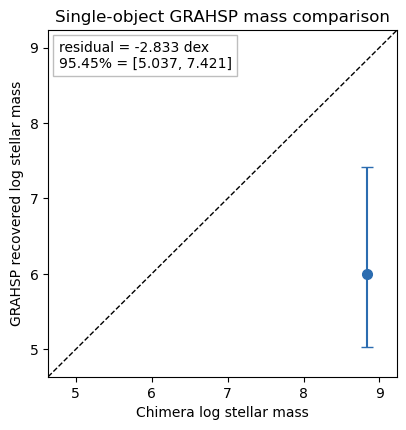

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.errorbar(
    [truth_logm],
    [recovered_logm],
    yerr=[[recovered_logm - logm_lo], [logm_hi - recovered_logm]],
    fmt="o",
    color="#2b6cb0",
    capsize=4,
    ms=7,
)
lims = [min(truth_logm, logm_lo) - 0.4, max(truth_logm, logm_hi) + 0.4]
ax.plot(lims, lims, color="black", ls="--", lw=1.0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Chimera log stellar mass")
ax.set_ylabel("GRAHSP recovered log stellar mass")
ax.set_title("Single-object GRAHSP mass comparison")
ax.text(
    0.03,
    0.97,
    f"residual = {residual:+.3f} dex\n95.45% = [{logm_lo:.3f}, {logm_hi:.3f}]",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
)
plt.show()

## Inspect Optional SED Products

If `MAKE_PLOTS=True`, GRAHSP writes posterior and SED products into a `grahsp_<object_id>_.../plots` directory below `output_dir`.

Plot directories: [PosixPath('/home/nicho/GRAHSP/grahspj/notebook_outputs/12_grahsp_chimera_stellar_mass/081636.18+294135.7_473476_0.0003/grahsp_081636.18+294135.7_473476_0.0003_varV1_maxgal13/plots')]
derived.csv exists: True
sed_mJy.csv.gz exists: True
Derived columns: ['stellar.mass_total', 'stellar.mass_alive', 'sfh.sfr', 'sfh.sfr100Myrs', 'agn.lumBolBBB', 'agn.lumBolTOR', 'agn.fracAGNDale', 'chi2', 's_sfh.sfr', 's_sfh.sfr100Myrs', 's_agn.lumBolBBB', 's_agn.lumBolTOR'] ...


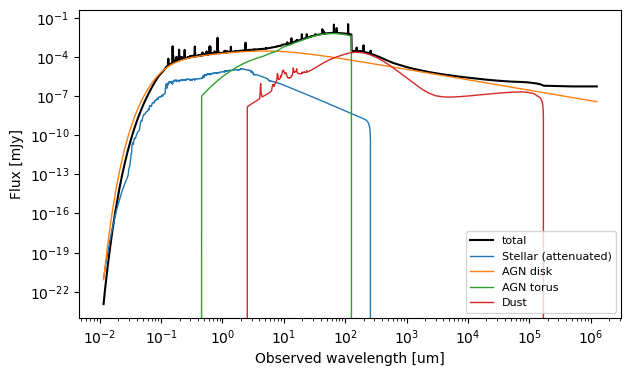

In [8]:
plot_dirs = sorted(output_dir.glob("grahsp_*/plots"))
print("Plot directories:", plot_dirs)

if plot_dirs:
    derived_path = plot_dirs[0] / "derived.csv"
    sed_path = plot_dirs[0] / "sed_mJy.csv.gz"
    print("derived.csv exists:", derived_path.is_file())
    print("sed_mJy.csv.gz exists:", sed_path.is_file())
    if derived_path.is_file():
        derived = Table.read(derived_path, format="ascii.csv")
        print("Derived columns:", derived.colnames[:12], "...")
    if sed_path.is_file():
        sed_table = Table.read(sed_path, format="ascii.csv")
        plt.figure(figsize=(7, 4))
        plt.plot(sed_table["wavelength"], sed_table["total"], color="black", lw=1.5, label="total")
        for col in ["Stellar (attenuated)", "AGN disk", "AGN torus", "Dust"]:
            if col in sed_table.colnames:
                plt.plot(sed_table["wavelength"], sed_table[col], lw=1.0, label=col)
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel("Observed wavelength [um]")
        plt.ylabel("Flux [mJy]")
        plt.legend(fontsize=8)
        plt.show()